# Installing libraries, loading AM and CTX Models

In [22]:

import numpy as np

import random
import json
import networkx as nx
import matplotlib.pyplot as plt
from decimal import Decimal
from copy import deepcopy
from collections import defaultdict
import json
import networkx as nx
from itertools import islice
from functools import partial
from deap import base, creator, tools, algorithms
import numpy as np



# Open the file from Path
with open("C:\\Users\\abhir\\Desktop\\Studienarbeit\\example_30T.json", 'r') as f:

    # Load the JSON data from the file
    json_data = json.load(f)

def Read_Parent_AM(json_data):     # Returning a dictionary about the Application graph
  AMx = json_data['application']
  #print("The Parent AM is ",AMx)
  return AMx

def Read_Parent_PM(json_data):     # Returning a dictionary about the Platform graph
  PMx = json_data['platform']
  return PMx


def construct_communication_costs_from_json(json_data):
  messages = json_data['application']['messages']
  communication_costs = {}

  for message in messages:
      sender = message['sender']
      receiver = message['receiver']
      size = message['size']

      if sender not in communication_costs:
          communication_costs[sender] = {receiver: size}
      else:
          communication_costs[sender][receiver] = size

  return communication_costs

def construct_task_dag_from_json(APP_MODEL): # where APP_MODELis an instance from the function Read_Parent_AM(json_data)
    # this function returns 2 lists one for task_dag (list of lists) for the successors
    # Another list tis the wcet_values showing the worst excution times for each job
    jobs = APP_MODEL['jobs']
    messages = APP_MODEL['messages']

    num_tasks = len(jobs)

    # Create a mapping of sender and receiver tasks for each message
    message_mapping = {}
    for message in messages:
        sender = message['sender']
        receiver = message['receiver']
        if sender not in message_mapping:
            message_mapping[sender] = [receiver]
        else:
            message_mapping[sender].append(receiver)

    # Create the task DAG
    task_dag = [[] for _ in range(num_tasks)]

    for job_id, successors in message_mapping.items():
        task_dag[job_id] = successors

    # Extract the WCET values
    wcet_values = [job['processing_times'] for job in jobs]

    return task_dag, wcet_values


def extract_message_list(APP_MODEL):
  # Returns a list of dictionaries for each meassage attribute where the keys for each message will be
  # id,sender,reciever,size
    messages = APP_MODEL['messages']                              # feteching messages (list of dictionaries)
    task_ids = [job['id'] for job in APP_MODEL['jobs']]           # creating a list of task_ids
    message_list = []                                                            # Initializing a list
    for msg in messages:
        sender_id = task_ids.index(msg['sender'])
        receiver_id = task_ids.index(msg['receiver'])
        message_size = msg['size']
        message_id = msg['id']
        message_info = {
            'id': message_id,
            'sender': sender_id,
            'receiver': receiver_id,
            'size': message_size
        }
        message_list.append(message_info)
    return message_list

def compute_makespan(schedule):    # passing the Re-construction function result
    # Extract end times from the schedule
    end_times = [info[2] for info in schedule.values()]
    # The makespan is the maximum end time
    makespan = max(end_times)
    return makespan

def plot_schedule(schedule):
    fig, ax = plt.subplots()

    processors = sorted(list(set([processor for processor, _, _ in schedule.values()])))
    colors = plt.cm.tab10(np.linspace(0, 1, len(processors)))

    for task, (processor, start_time, end_time) in schedule.items():
        color = colors[processor]
        ax.plot([start_time, end_time], [task, task], label=f'Processor {processor}', linewidth=10, marker='o', color=color)

    ax.set_xlabel('Time')
    ax.set_ylabel('Task')

    # Calculate the makespan and set x-axis limit
    makespan = max(end_time for _, (_, _, end_time) in schedule.items())
    ax.set_xlim(0, makespan)

    # Set y-axis ticks and labels
    plt.yticks(range(len(schedule)))
    plt.grid()
    plt.title("Task Schedule")

    # Create a custom legend without duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    plt.show()

def construct_graph_from_json(PLAT_MODEL):         # Function for constructing the PM , returns a graph object
    # Extract nodes and links from JSON data
    nodes = PLAT_MODEL['nodes']
    links = PLAT_MODEL['links']

    # Create an empty graph
    graph = nx.Graph()

    # Add nodes to the graph
    for node in nodes:
        node_id = node['id']
        node_type = 'processor' if not node['is_router'] else 'switch'
        graph.add_node(node_id, node_type=node_type)

    # Add edges (links) to the graph
    for link in links:
        start = link['start']
        end = link['end']
        graph.add_edge(start, end)

    return graph

def generate_all_path_indexes_with_costs(graph):
    processors = [node for node, data in graph.nodes(data=True) if data['node_type'] == 'processor']
    # creating a list with the processor nodes ids
    switches = [node for node, data in graph.nodes(data=True) if data['node_type'] == 'switch']
    # creating a list with the switche nodes ids

    def find_all_paths(source, target, path=[]): # A recursive function to find all paths between a give source node and target node, source and target are the iterables from the below for loop
      # This function uses a depth first search (DFS) to explore the paths
        path = path + [source]                    # Appending the "source" node to the path list, to keep track of nodes vistied in the list
        if source == target:
            return [path]
        if source not in graph:                    # checks for node presence in graph
            return []
        paths = []
        for node in graph[source]:                 # iterating through the current neighbors in graph
            if node not in path:
                newpaths = find_all_paths(node, target, path)  # calling the fuction recursively taking the neighbor node as a source node , target node is the same as the old one, path= path calculated so far
                for newpath in newpaths:
                    paths.append(newpath)
        return paths

    path_indexes = {}                             # Initialzing a dict. to store results (paths and costs)
    path_id = 0
    for source in processors:                     # iterating through the processors list in the PM [0,1,2]
        for target in processors:                 # iterating through processors list in PM [0,1,2], done to consider all pairs between source and target nodes
            if source == target:
                # Handle self-loop
                path_indexes[path_id] = {"path": [source, source], "cost": 0}
                path_id += 1
            else:
                all_paths = find_all_paths(source, target)
                all_paths = [path for path in all_paths if any(node in path for node in switches)] # filtering the paths to keep the ones with only one switch node
                if all_paths:
                    for path in all_paths:
                        # Compute the cost as the number of edges in the path
                        path_cost = len(path) - 1                                   # Computing the cost by subtracting 1 from the number of nodes in the path.
                        # Add the path, its ID, and its cost to the result
                        path_indexes[path_id] = {"path": path, "cost": path_cost}
                        path_id += 1
    return path_indexes



def get_processor_ids(data):
    processor_ids = [node['id'] for node in data['platform']['nodes'] if not node['is_router']]
    return processor_ids


def plot_schedule_w_dep(schedule, message_list):
    fig, ax = plt.subplots(figsize=(15, 10))  # Increase figure size

    processors = sorted(list(set([processor for processor, _, _ ,_ in schedule.values()])))
    colors = plt.cm.tab10(np.linspace(0, 1, len(processors)))

    for task, (processor, start_time, end_time,_) in schedule.items():
        color = colors[processors.index(processor)]
        ax.plot([start_time, end_time], [task, task], label=f'Processor {processor}', linewidth=10, marker='o', color=color)

    ax.set_xlabel('Time', fontsize=14)
    ax.set_ylabel('Task', fontsize=14)

    # Calculate the makespan and set x-axis limit
    makespan = max(end_time for _, (_, _, end_time,_) in schedule.items())
    ax.set_xlim(0, makespan)

    # Set y-axis ticks and labels
    plt.yticks(range(len(schedule)), fontsize=12)
    plt.xticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.title("Task Schedule", fontsize=16)

    # Create a custom legend without duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=12)

    # Add arrows to represent messages
    for message in message_list:
        sender = message['sender']
        receiver = message['receiver']
        if sender in schedule and receiver in schedule:
            sender_end = schedule[sender][2]
            receiver_start = schedule[receiver][1]
            ax.annotate("",
                        xy=(receiver_start, receiver),
                        xytext=(sender_end, sender),
                        arrowprops=dict(arrowstyle="->", color='black', lw=1.5))

    plt.tight_layout()
    plt.show()

AMx = Read_Parent_AM(json_data)
PMx = Read_Parent_PM(json_data)
successors, processing_times = construct_task_dag_from_json(AMx)
message_list = extract_message_list(AMx)
PLATFORM_GRAPH_OBJECT = construct_graph_from_json(PMx)
# all_path_indexes_with_costs = generate_all_path_indexes_with_costs(PLATFORM_GRAPH_OBJECT)
n_tasks = len(processing_times)
processor_ids = get_processor_ids(json_data)


################################################################################
# print("The path indexes with cost list is", all_path_indexes_with_costs)
# print("The message list is ", message_list)
# len(all_path_indexes_with_costs)

# finding k-shortest paths

In [23]:
# Extract nodes and links from the JSON data
nodes = json_data['platform']['nodes']
links = json_data['platform']['links']

# Create a graph
G = nx.Graph()

# Add nodes to the graph
for node in nodes:
    G.add_node(node['id'], is_router=node['is_router'])

# Add edges to the graph
for link in links:
    G.add_edge(link['start'], link['end'])

# Filter to get only processor nodes (not routers)
processor_nodes = [node['id'] for node in nodes if not node['is_router']]

# Define a function to find the k-shortest paths (using shortest path method)
def k_shortest_paths(G, source, target, k):
    return list(islice(nx.shortest_simple_paths(G, source, target), k))

# A function to calculate path cost based on number of routers in the list
def path_cost(G, path):
    return sum(1 for i in range(1, len(path)) if G.nodes[path[i]]['is_router'])

# Calculate the k-shortest paths with diversity between two processors
def diverse_k_shortest_paths(G, source, target, k):
    paths = k_shortest_paths(G, source, target, k)
    paths_with_costs = [(path, path_cost(G, path)) for path in paths]
    return paths_with_costs

# Dictionary to store the paths between processors with separate path_id and sub_path_id
paths_dict = {}

# Dictionary to store the merged paths with merged_id
merged_paths_dict = {}

# Find the k shortest paths between all pairs of processors
k = 4
path_id = 1

for i in range(len(processor_nodes)):
    for j in range(i + 1, len(processor_nodes)):
        source = processor_nodes[i]
        target = processor_nodes[j]
        paths = diverse_k_shortest_paths(G, source, target, k)
        
        # Create a sub-dictionary for this path_id
        sub_paths_dict = {}
        for sub_path_id, (path, cost) in enumerate(paths):
            sub_paths_dict[sub_path_id] = {'path': path, 'cost': cost}
            # Merge path_id and sub_path_id into a single merged_id as a string
            merged_id = f"{path_id}{sub_path_id}"
            merged_paths_dict[merged_id] = {'path': path, 'cost': cost}
        
        # Add the sub-dictionary to the main dictionary with path_id as key
        paths_dict[path_id] = sub_paths_dict
        
        # Increment the path_id for the next pair of processors
        path_id += 1

# Adding self-loops after calculating the diverse paths
for i in range(len(processor_nodes)):
    source = processor_nodes[i]
    target = source  # Self-loop
    
    # Self-loop represented as [source, target] with a cost of 1
    sub_paths_dict = {0: {'path': [source, target], 'cost': 1}}
    paths_dict[path_id] = sub_paths_dict
    
    # Merge path_id and sub_path_id into a single merged_id as a string for self-loop
    merged_id = f"{path_id}0"
    merged_paths_dict[merged_id] = {'path': [source, target], 'cost': 1}
    
    # Increment the path_id for the next processor
    path_id += 1

merged_paths_dict


{'10': {'path': [1, 4, 5, 2], 'cost': 2},
 '11': {'path': [1, 4, 8, 9, 5, 2], 'cost': 4},
 '12': {'path': [1, 4, 8, 12, 13, 9, 5, 2], 'cost': 6},
 '13': {'path': [1, 4, 8, 9, 10, 6, 5, 2], 'cost': 6},
 '20': {'path': [1, 4, 5, 6, 3], 'cost': 3},
 '21': {'path': [1, 4, 8, 9, 5, 6, 3], 'cost': 5},
 '22': {'path': [1, 4, 5, 9, 10, 6, 3], 'cost': 5},
 '23': {'path': [1, 4, 8, 9, 10, 6, 3], 'cost': 5},
 '30': {'path': [1, 4, 8, 7], 'cost': 2},
 '31': {'path': [1, 4, 5, 9, 8, 7], 'cost': 4},
 '32': {'path': [1, 4, 5, 6, 10, 9, 8, 7], 'cost': 6},
 '33': {'path': [1, 4, 5, 9, 13, 12, 8, 7], 'cost': 6},
 '40': {'path': [1, 4, 5, 6, 10, 11], 'cost': 4},
 '41': {'path': [1, 4, 8, 9, 10, 11], 'cost': 4},
 '42': {'path': [1, 4, 5, 9, 10, 11], 'cost': 4},
 '43': {'path': [1, 4, 8, 12, 13, 9, 10, 11], 'cost': 6},
 '50': {'path': [1, 4, 8, 12, 15], 'cost': 3},
 '51': {'path': [1, 4, 5, 9, 8, 12, 15], 'cost': 5},
 '52': {'path': [1, 4, 8, 9, 13, 12, 15], 'cost': 5},
 '53': {'path': [1, 4, 5, 9, 13, 12,

# Reconstructing base schedule

In [24]:
def reconstruct_schedule_with_precedenceX_updated(processor_ids, task_allocation, node_list, processing_times, message_list, message_path_index, all_path_indexes_with_costs, message_priority_ordering):
    # Create a deep copy of the message_list to avoid modifying the original data
    message_list_copy = deepcopy(message_list)

    num_processors = 18
    processors = [[] for _ in range(num_processors)]

    schedule = {}  # Dictionary to store the new schedule
    task_completion_times = [0] * len(node_list)  # List to store task completion times
    message_dict = defaultdict(list)  # Dictionary to store messages by receiver

    # Create a dictionary to map message ID to priority
    message_priority_dict = {message_id: priority for priority, message_id in enumerate(message_priority_ordering)}

    # Create a mapping from task ID to processor
    task_to_processor = {task_id: processor for task_id, processor in zip(node_list, task_allocation)}

    # Replace sender and receiver in message list with the corresponding processor
    updated_message_list = []  # Container for mapping the messages between the processors
    for message in message_list_copy:
        updated_message = {
            'id': message['id'],
            'sender': task_to_processor[message['sender']],
            'receiver': task_to_processor[message['receiver']],
            'size': message['size']
        }
        updated_message_list.append(updated_message)
    
    # Initialize the results list
    message_to_path_mapping = []

    # Initialize a dictionary to track the usage of path_ids
    path_usage = {path_id: 0 for path_id in message_path_index}

    # print('message_path_index in reconstruction' ,message_path_index)

    # Loop through each message and find the corresponding path
    for i, message in enumerate(updated_message_list):
        sender = message['sender']
        receiver = message['receiver']
        # Iterate through the message_path_index to find a matching path
        for path_id in message_path_index:
            # print(path_id)
            path_info = all_path_indexes_with_costs[path_id]
            path = path_info['path']
            
            # Check if the sender and receiver match the path's start and end
            if (path[0] == sender and path[-1] == receiver) or (path[-1] == sender and path[0] == receiver):
                # Check if this path has been used as many times as it appears in message_path_index
                if path_usage[path_id] < message_path_index.count(path_id):
                    message_to_path_mapping.append({'message_id': message['id'], 'path_id': path_id})
                    path_usage[path_id] += 1
                    break
    
    for idx, message in enumerate(message_list_copy):
        # Find the corresponding path_id from message_to_path_mapping
        message_mapping = next((m for m in message_to_path_mapping if m['message_id'] == message['id']), None)
        
        if message_mapping:
            path_id = message_mapping['path_id']
        else:
            path_id = '290'  # Set path_id to 290 if no mapping is found

        # Decode the path and cost using the path_id
        path = all_path_indexes_with_costs[path_id]["path"]
        path_cost = all_path_indexes_with_costs[path_id]["cost"]

        # Adjust the size of the message with the cost of the path
        message["size"] += path_cost

        # Append a tuple containing the sender, message size, message priority, path_id, and message_id to the receiver's list in the message_dict
        message_dict[message["receiver"]].append((message["sender"], message["size"], message_priority_dict[message["id"]], path_id, message["id"]))

        
    # Sort each receiver's list in message_dict by message priority
    for receiver, messages in message_dict.items():
        message_dict[receiver] = sorted(messages, key=lambda x: x[2])

    current_time_per_processor = [0] * num_processors  # List to track current time for each processor
    
    completed_tasks = set()  # Set of completed tasks
    ready_tasks = set(range(len(node_list)))  # Set of tasks ready to be processed

    while ready_tasks:
        task = ready_tasks.pop()
        task_id = node_list[task]
        processor = task_allocation[task]

        predecessors = message_dict[task_id]

        if all(p in completed_tasks for p, _, _, _, _ in predecessors):
            if predecessors:
                # Calculate the latest time when all predecessor tasks are completed including message sizes
                latest_predecessor_completion = max(
                    task_completion_times[sender] + size for sender, size, _, _, _ in predecessors
                )
                # Compare it with the current processor time and take the maximum
                start_time = max(current_time_per_processor[processor], latest_predecessor_completion)
            else:
                # If there are no predecessors, start at the current processor time
                start_time = current_time_per_processor[processor]

            # Calculate the total size of all messages from predecessors
            total_message_size = sum(size for _, size, _, _, _ in predecessors)

            # Calculate the end_time considering processing time and total message sizes
            end_time = start_time + processing_times[task_id] + total_message_size

            # Record the path information used by the predecessors
            path_info = [(sender, path_id, message_id) for sender, _, _, path_id, message_id in predecessors]
            schedule[task_id] = (processor, start_time, end_time, path_info)
            task_completion_times[task_id] = end_time

            # Update the current time of the processor to the end time of this task
            current_time_per_processor[processor] = end_time
            completed_tasks.add(task_id)
        else:
            ready_tasks.add(task)
    #print(message_path_index)
    return schedule

# SCHEDULE = reconstruct_schedule_with_precedenceX_updated(processor_ids,Processor, Tasks, processing_times, message_list, path_indices, merged_paths_dict, Message_orderings)
# print(SCHEDULE)

# Base GA

The Final genome for task order is [12, 3, 8, 17, 20, 18, 29, 6, 10, 7, 14, 15, 2, 21, 11, 9, 4, 26, 25, 5, 0, 24, 28, 27, 13, 19, 16, 22, 1, 23]
, for processor allocation [7, 7, 16, 7, 1, 2, 7, 11, 15, 15, 2, 7, 1, 15, 16, 15, 11, 16, 16, 16, 1, 7, 3, 11, 17, 2, 1, 15, 17, 2]
, message path index [1, 3, 0, 3, 1, 1, 0, 3, 0, 1, 1, 0, 3, 2, 1, 2, 2, 1, 0, 3, 3, 2, 3, 1, 0, 2, 3, 2, 2, 2, 2, 3, 0, 3, 0]
, and priority ordering [7, 9, 19, 23, 0, 8, 30, 29, 31, 32, 33, 1, 17, 26, 22, 12, 20, 4, 10, 14, 27, 2, 21, 24, 28, 11, 3, 18, 13, 5, 6, 34, 16, 15, 25]

The final schedule is {18: (2, 0, 8, []), 29: (7, 0, 7, []), 14: (2, 8, 14, []), 21: (15, 36, 71, [(18, '110', 16)]), 26: (16, 0, 7, []), 28: (3, 0, 9, []), 27: (11, 29, 51, [(28, '150', 31)]), 16: (1, 37, 67, [(14, '13', 9)]), 22: (15, 71, 117, [(26, '260', 28), (29, '203', 34)]), 23: (2, 14, 24, []), 6: (11, 53, 115, [(23, '103', 23), (18, '103', 15)]), 4: (11, 115, 175, [(21, '232', 20), (16, '42', 11)]), 25: (16, 45, 76, [(23, '12

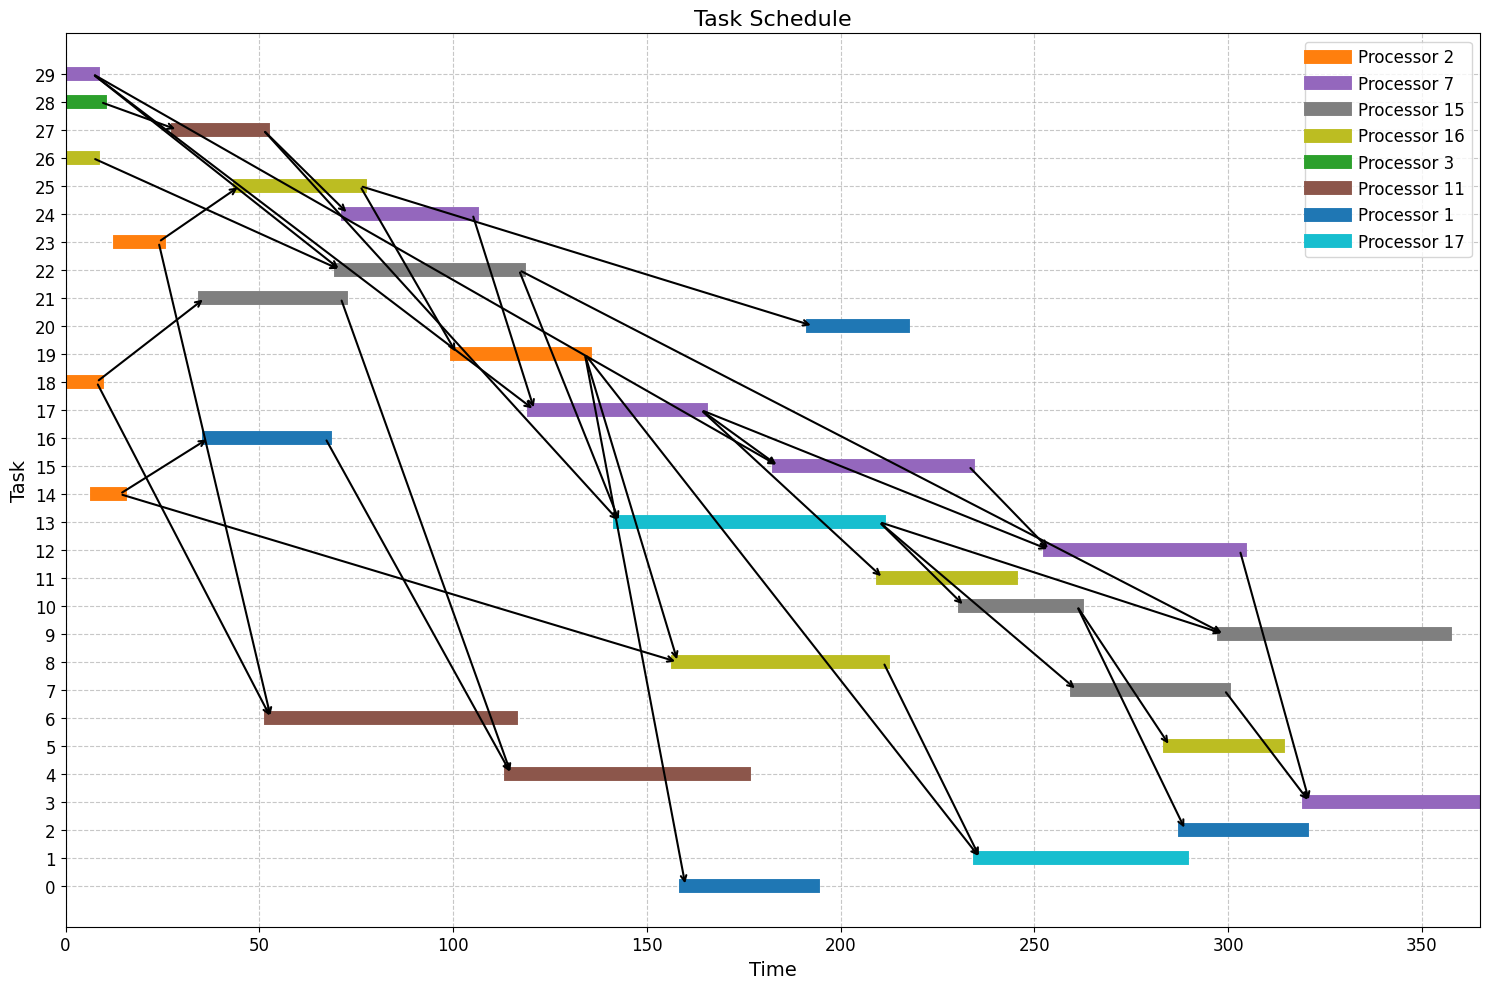

The schedule makespan is 365


In [25]:

def NEW_GA_V2(processor_ids,processing_times, message_list, all_path_indexes_with_costs, pop_size=100, cxpb=0.4, mutpb=0.6, ngen=50):
    # Create a FitnessMin class for minimization and set the weights to (-1.0,).
    creator.create("FitnessMin", base.Fitness, weights=(-100.0,))
    # Create the Individual class as a list with the FitnessMin class as the fitness attribute.
    creator.create("Individual", list, fitness=creator.FitnessMin)
    
    toolbox = base.Toolbox()

    # Parameters
    num_tasks = len(processing_times)  # Number of jobs in task graph
    num_message = len(message_list)    # Number of messages
    predefined_processors = processor_ids    # Predefined processor values
    message_list_ids = [message['id'] for message in message_list]


    # Define the initialization function for the task order in the individual
    def init_task_order():
        return random.sample(range(num_tasks), num_tasks)  # Returns a list of random numbers in the range of num_tasks

    # Define the processor allocation initialization function
    def processor_allocation(n_task, predefined_values):
        return [random.choice(predefined_values) for _ in range(n_task)]  # Random list for processor allocation from predefined values


    def message_priority_ordering(n_messages, defined_values):
        # Ensure n_messages is positive and not greater than the number of defined values
        if n_messages <= 0 or n_messages > len(defined_values):
            raise ValueError("n_messages must be greater than 0 and not exceed the number of defined values")
        # Use random.sample to ensure unique values
        return random.sample(defined_values, n_messages)
    

    # Add the message path index initialization function
    def init_message_path_index(n_messages):
        return [random.choice([0, 1, 2, 3]) for _ in range(n_messages)]

    # Combined Individual with new message_path_index
    def create_individual():
        individual = []
        individual.extend(toolbox.task_order())
        individual.extend(toolbox.processor_allocation())
        individual.extend(toolbox.message_priority_ordering())
        individual.extend(toolbox.message_path_index())  # Include message_path_index
        return individual

    # Register the initialization functions in the DEAP toolbox
    toolbox.register("task_order", init_task_order)
    toolbox.register("processor_allocation", processor_allocation, n_task=num_tasks, predefined_values=predefined_processors)
    toolbox.register("message_priority_ordering", message_priority_ordering, n_messages=num_message,defined_values = message_list_ids )
    toolbox.register("message_path_index", init_message_path_index, n_messages=num_message)
    toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # Evaluation function
    def compute_makespan(schedule):
        # Extract end times from the schedule
        end_times = [info[2] for info in schedule.values()]
        # The makespan is the maximum end time
        makespan = max(end_times)
        return makespan
    
    ####################################################### New functions to get correct paths #################################################
    # Updating the Message list to be processorwise and adding the corresponding index 
    # tasks ==> task_order
    # task_allaocation ==> processors
    # message_priority ordering  ==> message_orderings
    # Message_path_index ==> path_indices

    def ComputeMappingsAndPaths(message_list, tasks, processors, message_orderings, path_indices):
        #print('message_orderings',message_orderings)
        # print('path_indices',path_indices)
        message_list_copy = deepcopy(message_list)
        
        # Create a dictionary that maps task ids to processor ids
        task_to_processor = {task: processors[i] for i, task in enumerate(tasks)}
        
        updated_message_list = []  # Container for mapping the messages between the processors
        
        # Create a mapping between message IDs (orderings) and path indices
        message_to_path_mapping = {message_orderings[i]: path_indices[i] for i in range(len(message_orderings))}
        
        for message in message_list_copy:
            # Find the corresponding path index using the message ID
            path_index = message_to_path_mapping.get(message['id'], None)

            if task_to_processor[message['sender']] == task_to_processor[message['receiver']]:
                path_index = 0
            
            updated_message = {
                'id': message['id'],
                'sender': task_to_processor[message['sender']],
                'receiver': task_to_processor[message['receiver']],
                'size': message['size'],
                'path_index': path_index  # Add the path index to the updated message
            }
            updated_message_list.append(updated_message)
        
        return updated_message_list


    def find_suitable_paths(updated_message_list, merged_paths_dict):
        #print('updated_message_list',updated_message_list)
        selected_paths = []
        
        for message in updated_message_list:
            sender = message['sender']
            receiver = message['receiver']
            path_index_str = str(message['path_index'])

            valid_path_ids = set()
            
            # Iterate through merged_paths_dict to find all valid paths
            for pid, details in merged_paths_dict.items():
                path = details['path']
                
                if ((path[0] == sender and path[-1] == receiver) or 
                    (path[0] == receiver and path[-1] == sender)) and pid.endswith(path_index_str):
                    valid_path_ids.add(pid)
            
            # Select the valid path_id if found, else set to None
            path_id = next(iter(valid_path_ids), None)
            
            selected_paths.append(path_id)
            #print(selected_paths)
        
        return selected_paths


    ######################################################### End of new functions ######################################################################
    def evaluate(individual, processing_times, message_list, all_path_indexes_with_costs):
        # Split individual into its components
        task_order_len = num_tasks
        processor_allocation_len = num_tasks
        message_priority_ordering_len = num_message
        message_path_index_len = num_message
        # print('best_ind',individual)
        # print('len best_ind', len(individual))
        task_order = individual[:task_order_len]
        processor_allocation = individual[task_order_len:task_order_len + processor_allocation_len]
        message_priority_ordering = individual[task_order_len + processor_allocation_len : task_order_len + processor_allocation_len + message_priority_ordering_len]
        message_path_index = individual[task_order_len + processor_allocation_len + message_priority_ordering_len:]  # New component
        # print('message_path_index in evaluate ',message_path_index)
        # print()
        # print('task_order',task_order)
        # print()
        # print('processor_allocation',processor_allocation)
        # print()
        # print('message_priority_ordering',message_priority_ordering)
        # print()
        # print('message_path_index',message_path_index)


        ############################# Define the function to get the message paths #############################################
        updated_list  = ComputeMappingsAndPaths(message_list, task_order, processor_allocation,message_priority_ordering,message_path_index)
        Selected_paths = find_suitable_paths(updated_list, all_path_indexes_with_costs)


        schedule = reconstruct_schedule_with_precedenceX_updated(processor_ids,processor_allocation, task_order, processing_times, message_list, Selected_paths, all_path_indexes_with_costs, message_priority_ordering)
        makespan = compute_makespan(schedule)
        fitness =  makespan  # Fitness is the inverse of makespan for minimization
        return fitness,

    # Register the evaluation function
    toolbox.register("evaluate", evaluate, processing_times=processing_times, message_list=message_list, all_path_indexes_with_costs=all_path_indexes_with_costs)

    # Register selection operator
    toolbox.register("select", tools.selTournament, tournsize=3)

    # Register the crossover operator (Permutation encoded)
    def mate(ind1, ind2, task_order_len):
        # Copy the individuals
        child1, child2 = toolbox.clone(ind1), toolbox.clone(ind2)

        # Apply PMX crossover to task_order
        tools.cxOnePoint(child1[:task_order_len], child2[:task_order_len])

        # Return the modified individuals
        return child1, child2

    toolbox.register("mate", mate, task_order_len=num_tasks)

    # Mutation functions
    def mutation_task_order(individual, task_order_len):
        task_order = deepcopy(individual[:task_order_len])
        indices = random.sample(range(task_order_len), 2)  # Select two random indices
        task_order[indices[0]], task_order[indices[1]] = task_order[indices[1]], task_order[indices[0]]  # Swap the elements at the selected indices
        individual[:task_order_len] = task_order
        return individual,

    def mutation_processor_allocation(individual, task_order_len, processor_allocation_len, predefined_values):
        processor_allocation = deepcopy(individual[task_order_len:task_order_len + processor_allocation_len])
        for i in range(len(processor_allocation)):
            if random.random() < 0.05:  # Mutate with a certain probability
                processor_allocation[i] = random.choice(predefined_values)
        individual[task_order_len:task_order_len + processor_allocation_len] = processor_allocation
        return individual,


    # def mutation_message_priority_ordering(individual, task_order_len, processor_allocation_len, message_path_index_len):
    #     message_priority_ordering = individual[task_order_len + processor_allocation_len :]
    #     tools.mutShuffleIndexes(message_priority_ordering, indpb=0.05)
    #     individual[task_order_len + processor_allocation_len  :] = message_priority_ordering
    #     return individual,


    def mutation_message_priority_ordering(individual, task_order_len, processor_allocation_len, message_path_index_len, message_list):
        # Extract the message priority ordering part of the individual
        message_priority_ordering = deepcopy(individual[task_order_len + processor_allocation_len : task_order_len + processor_allocation_len + message_path_index_len])
        
        # Shuffle the message priority ordering
        tools.mutShuffleIndexes(message_priority_ordering, indpb=0.05)
        
        # Ensure uniqueness
        unique_ids = list({msg['id'] for msg in message_list})  # Get unique IDs from message_list
        random.shuffle(unique_ids)  # Shuffle to introduce randomness

        # Replace duplicates in the shuffled message_priority_ordering
        seen = set()
        for i in range(len(message_priority_ordering)):
            if message_priority_ordering[i] in seen:
                # If the current element is a duplicate, replace it with an unused unique ID
                for uid in unique_ids:
                    if uid not in seen:
                        message_priority_ordering[i] = uid
                        seen.add(uid)
                        break
            else:
                seen.add(message_priority_ordering[i])

        # Ensure the list is exactly of length message_path_index_len
        message_priority_ordering = message_priority_ordering[:message_path_index_len]

        # Replace the individual's message priority ordering with the updated unique list
        individual[task_order_len + processor_allocation_len: task_order_len + processor_allocation_len + message_path_index_len] = message_priority_ordering
        
        return individual,


    def mutation_message_path_index(individual, task_order_len, processor_allocation_len, message_priority_ordering_len, message_path_index_len):
        message_path_index = deepcopy(individual[task_order_len + processor_allocation_len + message_priority_ordering_len:])
        for i in range(len(message_path_index)):
            if random.random() < 0.05:  # Mutate with a certain probability
                # Mutate the value at index i to another value within the allowed range [0, 1, 2, 3]
                message_path_index[i] = random.choice([0, 1, 2, 3])
        individual[task_order_len + processor_allocation_len + message_priority_ordering_len:] = message_path_index
        return individual,


    # Register the mutation operators
    toolbox.register("mutate_task_order", mutation_task_order, task_order_len=num_tasks)
    toolbox.register("mutate_processor_allocation", mutation_processor_allocation, task_order_len=num_tasks, processor_allocation_len=num_tasks, predefined_values=predefined_processors)
    toolbox.register("mutate_message_priority_ordering", mutation_message_priority_ordering, task_order_len=num_tasks, processor_allocation_len=num_tasks, message_path_index_len=num_message,message_list =message_list)
    toolbox.register("mutate_message_path_index", mutation_message_path_index, task_order_len=num_tasks, processor_allocation_len=num_tasks,message_priority_ordering_len=num_message, message_path_index_len=num_message)


    # Create an initial population
    pop = toolbox.population(n=pop_size)

    # Evaluate the entire population
    fitnesses = map(toolbox.evaluate, pop)
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    # Crossover probability and mutation probability
    CXPB, MUTPB = cxpb, mutpb

    # Extract all the fitnesses
    fits = [ind.fitness.values[0] for ind in pop]

    NGEN = ngen # Number of generations
    # Begin the evolution
    for g in range(NGEN):
      
        # A new generation
        offspring = toolbox.select(pop, len(pop))
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate_task_order(mutant)
                toolbox.mutate_processor_allocation(mutant)
                toolbox.mutate_message_priority_ordering(mutant)
                toolbox.mutate_message_path_index(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # The population is entirely replaced by the offspring
        pop[:] = offspring

    # Print the best individual
    best_ind = tools.selBest(pop, 1)[0]

    task_order_len = num_tasks
    processor_allocation_len = num_tasks
    # message_path_index_len = num_message
    message_priority_ordering_len = num_message

    task_order_ = best_ind[:task_order_len]
    processor_allocation_ = best_ind[task_order_len:task_order_len + processor_allocation_len]
    message_priority_ordering_ = best_ind[task_order_len + processor_allocation_len : task_order_len + processor_allocation_len + message_priority_ordering_len]
    message_path_index_ = best_ind[task_order_len + processor_allocation_len + message_priority_ordering_len:]


    # Fix
    updated_list_ = ComputeMappingsAndPaths(message_list, task_order_, processor_allocation_,message_priority_ordering_,message_path_index_)
    Selected_paths_ = find_suitable_paths(updated_list_, all_path_indexes_with_costs)


    scheduleFinal = reconstruct_schedule_with_precedenceX_updated(processor_ids,processor_allocation_, task_order_, processing_times, message_list, Selected_paths_, all_path_indexes_with_costs, message_priority_ordering_)
    
    print("The Final genome for task order is {}\n, for processor allocation {}\n, message path index {}\n, and priority ordering {}\n".format(task_order_, processor_allocation_, message_path_index_, message_priority_ordering_))
    print('The final schedule is {}'.format(scheduleFinal))
    
    Final_genome = [task_order_, processor_allocation_,  message_priority_ordering_,message_path_index_]

    
    makespan_final = compute_makespan(scheduleFinal)
    return makespan_final, scheduleFinal, Final_genome

makespan, S_0, Final_genome_base_1= NEW_GA_V2(processor_ids,processing_times, message_list, merged_paths_dict, pop_size=100, cxpb=0.4, mutpb=0.6, ngen=50)
print("Best Makespan: ", makespan)

plot_schedule_w_dep(S_0, message_list)
Base_schedule_makespan = compute_makespan(S_0)
print('The schedule makespan is {}'.format(compute_makespan(S_0)))



# Appedending the results to the schedules and the genomes dictionaries

In [26]:
schedules_dictionary_pareto = {}
schedules_dictionary_pareto['Base_schedule']=  S_0,compute_makespan(S_0),(0,(0,0,0,0))

In [27]:
print(schedules_dictionary_pareto)

{'Base_schedule': ({18: (2, 0, 8, []), 29: (7, 0, 7, []), 14: (2, 8, 14, []), 21: (15, 36, 71, [(18, '110', 16)]), 26: (16, 0, 7, []), 28: (3, 0, 9, []), 27: (11, 29, 51, [(28, '150', 31)]), 16: (1, 37, 67, [(14, '13', 9)]), 22: (15, 71, 117, [(26, '260', 28), (29, '203', 34)]), 23: (2, 14, 24, []), 6: (11, 53, 115, [(23, '103', 23), (18, '103', 15)]), 4: (11, 115, 175, [(21, '232', 20), (16, '42', 11)]), 25: (16, 45, 76, [(23, '120', 24)]), 24: (7, 73, 105, [(27, '190', 30)]), 17: (7, 121, 164, [(29, '320', 33), (24, '320', 25)]), 13: (17, 143, 210, [(27, '253', 29), (22, '271', 22)]), 19: (2, 101, 134, [(25, '122', 26)]), 0: (1, 160, 193, [(19, '13', 17)]), 20: (1, 193, 216, [(25, '63', 27)]), 10: (15, 232, 261, [(13, '271', 7)]), 7: (15, 261, 299, [(13, '272', 5)]), 15: (7, 184, 233, [(29, '320', 32), (17, '320', 14)]), 2: (1, 289, 319, [(10, '52', 2)]), 12: (7, 254, 303, [(15, '320', 10), (17, '320', 13)]), 3: (7, 321, 365, [(7, '201', 0), (12, '320', 4)]), 9: (15, 299, 356, [(22, 